# LiDAR Point Cloud Data

LiDAR ("Light Detection and Ranging") scans a landscape from a plane and
records millions of 3D points: `(x, y, z)` plus a *classification* code
that says what kind of surface each point bounced off (ground,
vegetation, building, ...). In this notebook we:

1. Download one or two 1km x 1km LiDAR tiles for the German state of
   Thuringia.
2. Look at the raw point cloud (the **Digital Surface Model**, DSM - every
   point, including treetops and roofs).
3. Keep only the *ground* points (the **Digital Terrain Model**, DTM - bare
   earth, as if all vegetation and buildings were removed).
4. Subtract the two to get the **Canopy Height Model** (CHM) - how tall
   everything standing on the ground is.

The data is published at
https://www.geoportal-th.de/de-de/Downloadbereiche/Download-Offene-Geodaten-Th%C3%BCringen/Download-H%C3%B6hendaten
under the [DL-DE->BY-2.0](https://www.govdata.de/dl-de/by-2-0) license,
with coordinates in [EPSG:25832](https://epsg.io/25832).

**Simplifications vs. a "production" version of this notebook:** the
original approach used `dask` to parallelize downloading and processing
*many* tiles across a whole state. For the 1-2 tiles we use here, plain
`numpy`/`pandas` is easier to read and just as fast - `dask` only starts
paying off once you're working with more tiles than fit comfortably in
memory. If you scale this up to the full Thuringia dataset, revisiting
`dask.bag`/`dask.array` for the download-and-read step is worth it.

**A note on network access:** downloading a tile requires reaching
`geoportal.geoportal-th.de`. If that's not reachable (e.g. no internet
access), this notebook falls back to a small synthetic point cloud with
the same structure (ground + "trees" above it), so every cell below still
runs and produces a real plot.

## Setup

In [1]:
# If a library below is missing, uncomment the matching line and run this cell.
#%pip install requests
#%pip install laspy
#%pip install numpy
#%pip install pandas
#%pip install scipy
#%pip install matplotlib
#%pip install laspy lazrs


In [1]:
import os
import zipfile
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen

import laspy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.interpolate import griddata

## Choose Tiles

Each tile is named by its lower-left corner coordinate (in km) in the
EPSG:25832 grid. The full Thuringia dataset spans `x` in `631..756` and
`y` in `5562..5722` - that's well over 10,000 tiles! We only work with
two neighboring tiles here so downloads and plots stay fast.

In [2]:
# all tiles (for reference - not used below, would be thousands of downloads)
full_x_range = range(631, 757)
full_y_range = range(5562, 5723)

# small subset we'll actually use
x_range = range(634, 635)
y_range = range(5612, 5614)
tile_coords = [(x, y) for x in x_range for y in y_range]
tile_coords

[(634, 5612), (634, 5613)]

In [3]:
def tile_url(x, y):
    # Build the download URL for a single 1km x 1km tile.
    return f"https://geoportal.geoportal-th.de/hoehendaten/LAS/las_2014-2019/las_{x}_{y}_1_th_2014-2019.zip"


urls = [tile_url(x, y) for x, y in tile_coords]
urls

['https://geoportal.geoportal-th.de/hoehendaten/LAS/las_2014-2019/las_634_5612_1_th_2014-2019.zip',
 'https://geoportal.geoportal-th.de/hoehendaten/LAS/las_2014-2019/las_634_5613_1_th_2014-2019.zip']

## Reading a Tile

`las_reader_from_tile` downloads one tile's ZIP file (if reachable),
unzips it in memory, and opens the `.laz` point cloud inside with
`laspy`. If the download fails, it generates a small synthetic tile with
the same fields (`x`, `y`, `z`, `classification`) instead - ground points
on a gently rolling surface, plus scattered "tree" points above it.

In [4]:
def make_synthetic_tile_points(x, y, seed=None, n_ground=4000, n_vegetation=1500):
    # Build a synthetic point cloud for one 1km x 1km tile, standing in for
    # a real LiDAR download. Coordinates are local (0-1000m within the
    # tile) purely for readability of the plots below.
    rng = np.random.default_rng(seed)

    # --- ground points: a smooth rolling surface + a bit of scan noise ---
    gx = rng.uniform(0, 1000, n_ground)
    gy = rng.uniform(0, 1000, n_ground)
    gz = (
        200  # base elevation in meters
        + 8 * np.sin(gx / 150) * np.cos(gy / 150)  # rolling hills
        + rng.normal(0, 0.15, n_ground)  # small scan noise
    )
    ground = pd.DataFrame({"x": gx, "y": gy, "z": gz, "classification": 2})  # 2 = ground

    # --- vegetation points: scattered clumps ("trees") sitting on the ground ---
    n_trees = 60
    tree_x = rng.uniform(0, 1000, n_trees)
    tree_y = rng.uniform(0, 1000, n_trees)
    tree_height = rng.uniform(5, 20, n_trees)
    points_per_tree = n_vegetation // n_trees

    veg_rows = []
    for tx, ty, th in zip(tree_x, tree_y, tree_height):
        ground_z = 200 + 8 * np.sin(tx / 150) * np.cos(ty / 150)
        vx = tx + rng.normal(0, 2.5, points_per_tree)
        vy = ty + rng.normal(0, 2.5, points_per_tree)
        vz = ground_z + rng.uniform(0.5, th, points_per_tree)
        veg_rows.append(pd.DataFrame({"x": vx, "y": vy, "z": vz, "classification": 5}))  # 5 = high vegetation
    vegetation = pd.concat(veg_rows, ignore_index=True)

    tile_points = pd.concat([ground, vegetation], ignore_index=True)
    tile_points["tile"] = f"{x}_{y}"
    return tile_points


def read_tile(x, y):
    # Try to download and read the real tile; fall back to a synthetic one
    # (with a fixed seed per tile, so results are reproducible) if that fails.
    url = tile_url(x, y)
    try:
        with urlopen(url, timeout=10) as response:
            zip_bytes = response.read()
        with zipfile.ZipFile(BytesIO(zip_bytes)) as zf:
            laz_name = next(n for n in zf.namelist() if n.endswith(".laz"))
            with zf.open(laz_name) as f:
                las = laspy.read(f)
        df = pd.DataFrame(
            {
                "x": np.asarray(las.x, dtype="float32"),
                "y": np.asarray(las.y, dtype="float32"),
                "z": np.asarray(las.z, dtype="float32"),
                "classification": np.asarray(las.classification),
            }
        )
        df["tile"] = f"{x}_{y}"
        print(f"Downloaded tile {x}_{y}: {len(df):,} points.")
        return df, True
    except Exception as err:
        print(f"Could not download tile {x}_{y} ({err}). Using synthetic points instead.")
        seed = hash((x, y)) % (2**32)
        df = make_synthetic_tile_points(x, y, seed=seed)
        return df, False

In [5]:
tile_frames = []
using_real_data = True
for x, y in tile_coords:
    df_tile, was_real = read_tile(x, y)
    tile_frames.append(df_tile)
    using_real_data = using_real_data and was_real

points = pd.concat(tile_frames, ignore_index=True)
len(points)

Downloaded tile 634_5612: 8,094,602 points.
Downloaded tile 634_5613: 8,399,171 points.


16493773

## Explore the Point Cloud

In [6]:
points.head()

,x,y,z,classification,tile
0,634062.5000,5612438.5,630.179993,2,634_5612
1,634062.6875,5612440.0,637.219971,13,634_5612
2,634062.5000,5612440.0,630.409973,2,634_5612
3,634062.6875,5612440.5,637.080017,13,634_5612
4,634062.5625,5612440.5,630.549988,2,634_5612


In [7]:
# classification codes present in the data (see the ASPRS LAS spec:
# https://www.asprs.org/a/society/committees/standards/asprs_las_format_v11.pdf
# - 2 = ground, 5 = high vegetation, among others)
points["classification"].value_counts()

classification
13    10433264
2      6058592
30        1917
Name: count, dtype: int64

In [8]:
# how many points per tile, and estimated size in memory (x, y, z as float32)
points_per_tile = points.groupby("tile").size()
total_points = len(points)
bytes_estimate_gib = total_points * 3 * 4 / 2**30
points_per_tile, total_points, bytes_estimate_gib

(tile
 634_5612    8094602
 634_5613    8399171
 dtype: int64,
 16493773,
 0.18433227762579918)

## Digital Surface Model (DSM)

The DSM is simply *every* point - ground, trees, anything the laser hit.
We randomly sample points (plotting millions of points is slow and not
much more informative) and color by height.

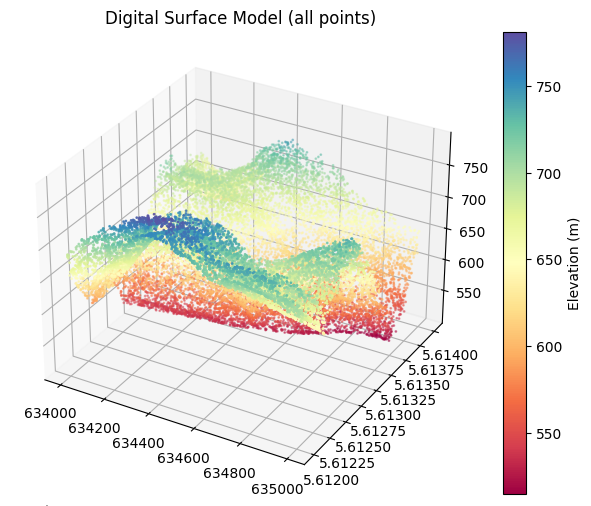

In [9]:
SAMPLE_SIZE = min(20_000, len(points))
sample = points.sample(SAMPLE_SIZE, random_state=0)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
sc = ax.scatter(sample["x"], sample["y"], sample["z"], c=sample["z"], s=1, cmap="Spectral")
ax.set_title("Digital Surface Model (all points)")
fig.colorbar(sc, ax=ax, label="Elevation (m)")
plt.show()

## Digital Terrain Model (DTM)

Now we split points into *ground* (classification code 2) and everything
else, and look only at the ground - this approximates the bare-earth
surface with vegetation and buildings removed.

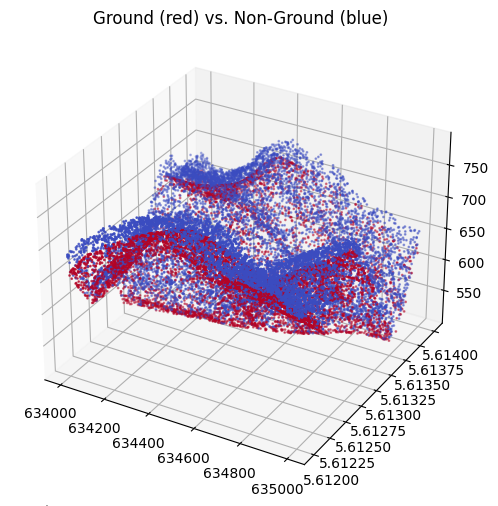

In [10]:
is_ground = sample["classification"] == 2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(sample["x"], sample["y"], sample["z"], c=is_ground, s=1, cmap="coolwarm")
ax.set_title("Ground (red) vs. Non-Ground (blue)")
plt.show()

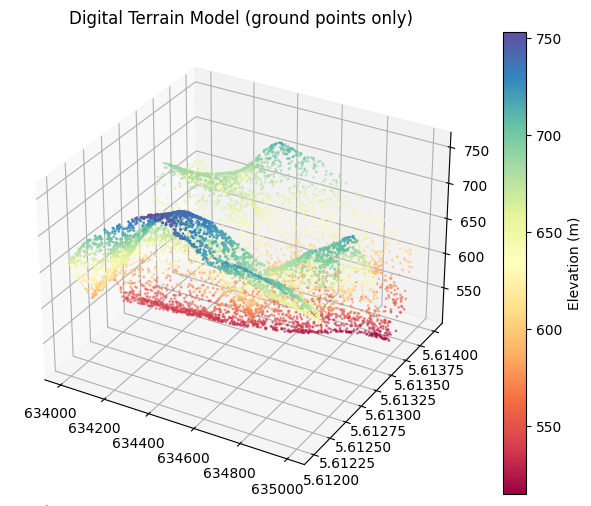

In [11]:
ground_points = sample[is_ground]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
sc = ax.scatter(ground_points["x"], ground_points["y"], ground_points["z"],
                 c=ground_points["z"], s=1, cmap="Spectral")
ax.set_title("Digital Terrain Model (ground points only)")
fig.colorbar(sc, ax=ax, label="Elevation (m)")
plt.show()

### Interpolating the Ground

Non-ground points (trees, buildings...) don't have a ground elevation of
their own - the laser never reached the ground underneath them. We
estimate it by interpolating between the nearby ground points we *do*
have, using `scipy.interpolate.griddata`.

In [12]:
non_ground_points = sample[~is_ground]

interpolated_ground_z = griddata(
    points=ground_points[["x", "y"]].to_numpy(),
    values=ground_points["z"].to_numpy(),
    xi=non_ground_points[["x", "y"]].to_numpy(),
    method="linear",
)
interpolated_ground_z[:5]

array([606.91164326, 716.12020396, 647.69864737, 569.76936336,
       681.3385151 ])

## Canopy Height Model (CHM)

Subtracting the interpolated ground elevation from each non-ground
point's actual elevation gives its height *above the ground* - e.g. how
tall that part of a tree is, rather than its absolute elevation above sea
level.

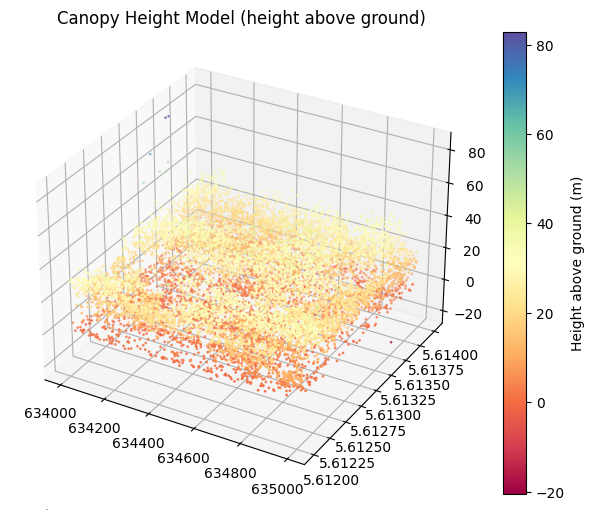

In [13]:
heights_above_ground = non_ground_points["z"].to_numpy() - interpolated_ground_z
# drop any points where interpolation failed (outside the convex hull of ground points)
valid = ~np.isnan(heights_above_ground)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
sc = ax.scatter(
    non_ground_points["x"].to_numpy()[valid],
    non_ground_points["y"].to_numpy()[valid],
    heights_above_ground[valid],
    c=heights_above_ground[valid],
    s=1,
    cmap="Spectral",
)
ax.set_title("Canopy Height Model (height above ground)")
fig.colorbar(sc, ax=ax, label="Height above ground (m)")
plt.show()

## Wrap-up

- If the download messages above said *"Downloaded tile ..."*, this ran
  on real LiDAR data from Thuringia.
- If they said *"Using synthetic points instead"*, the notebook still
  produced real DSM/DTM/CHM plots, just from a generated stand-in point
  cloud (this will happen in sandboxed environments without internet
  access). Re-run somewhere with internet access for the real tiles - no
  code changes needed.
- To cover more tiles, widen `x_range`/`y_range` in the **Choose Tiles**
  section. If that grows into hundreds or thousands of tiles, revisit
  `dask` for parallel downloading and processing.